In [1]:
from IPython.display import display, HTML, Image
display(HTML("<style>.container { width:100% !important; }</style>"))

import pickle
import torch
import io 
from hashlib import md5
from typing import Any, Dict, List

import fire
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

from google.cloud import bigquery, storage

from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint 

from datetime import datetime
pd.set_option('display.max_colwidth', None)


from exp_tools.stat_tools import * 

import plotly.offline as pyo
import plotly.io as pio
pio.renderers.default = 'iframe'


In [2]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle = '--', color = kwargs.get("color", "g"), alpha = 0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color = kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean()+xal, yal, tx_mean, **txkw)


def plot_distribution(df, metric, **kwargs):
    g = sns.FacetGrid(
        data=df,
        aspect=3, height = 5,
        hue = 'variant', row = kwargs.get('row',None)
    ) 
    g.map(sns.distplot, metric, hist=kwargs.get('displot_hist',False), kde_kws={'bw': kwargs.get('kde_bandwidth','silverman')})
    g.map(vertical_plot_lines, metric, xal=  kwargs.get('xal',0.10), yal=kwargs.get('yal',0.5))
    g.fig.suptitle("Distribution between variants - {}".format(metric))
    g.set_xlabels("{}".format(metric))
    g.set_ylabels("density")
    g.set(xlim = kwargs.get('xlim', (-10,10)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color="black", ls=':')

In [3]:
from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
from statsmodels.stats.proportion import proportion_confint 

def calculate_req_traffic_for_power(alpha, beta, base_rate, expected_effect):
    za = norm.ppf(1 - alpha/2)
    zb = norm.ppf(1 - beta)
    mde = (base_rate * expected_effect) 
    sigma = np.sqrt((base_rate) * (1-base_rate))
    sample_size_variant = 2 * (sigma**2) * (za + zb)**2 / (mde**2)
    return int(sample_size_variant)

def calculate_mde_from_traffic(alpha, beta, base_rate, n_variant):
    za = norm.ppf(1 - alpha/2)
    zb = norm.ppf(1 - beta)
    sigma = np.sqrt((base_rate) * (1-base_rate))
    
    mde = np.sqrt(2 * (sigma**2) * (za + zb)**2 / n_variant)
    
#     print(
#         f'MDE (percentage effect) = {mde/base_rate:.2%}',
#         f'\nMDE (absolute effect) = {base_rate:.2%} +- {mde:.2%}',
#         f'\nEffect identifiable outside the range [{base_rate - mde:.2%},{base_rate + mde:.2%}]\n------'
#     )
    
    return mde / BASE_RATE


ALPHA = 0.05
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
N_VARIANT = 20000

EXPECTED_UPLIFT_PERC = 0.05
N_VARIANTS = 2
N_DAYS = 14

print(
      f'MDE (absolute effect) = +- {BASE_RATE*(1+EXPECTED_UPLIFT_PERC) - BASE_RATE:.2%}',
      f'\nEffect identifiable outside the range [{BASE_RATE*(1-EXPECTED_UPLIFT_PERC):.2%},{BASE_RATE*(1+EXPECTED_UPLIFT_PERC):.2%}]\n------'
)

req_total_exp_traffic = calculate_req_traffic_for_power(
    alpha=ALPHA, 
    beta=BETA, 
    base_rate=BASE_RATE, 
    expected_effect=EXPECTED_UPLIFT_PERC)

req_daily_traffic = req_total_exp_traffic / (N_DAYS)
print(f'{req_total_exp_traffic:.0f} \t=== Total required unique visitors per variant')
print(f'{req_daily_traffic:.0f} \t=== Required daily unique visitors per variant, for experiment run of {N_DAYS} days')
print(f'\n{req_total_exp_traffic*N_VARIANTS:.0f} \t=== Total required visitors\n--------')

calculate_mde_from_traffic(
    alpha=ALPHA, 
    beta=BETA, 
    base_rate=BASE_RATE, 
    n_variant=req_total_exp_traffic
) 

MDE (absolute effect) = +- 0.25% 
Effect identifiable outside the range [4.75%,5.25%]
------
119302 	=== Total required unique visitors per variant
8522 	=== Required daily unique visitors per variant, for experiment run of 14 days

238604 	=== Total required visitors
--------


0.0500002036764108

# Simulating non-inferiority

In [4]:
ALPHA = 0.05 # two sided
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
TRUE_EFFECT = 0.07
SAMPLE_SIZE = int(250000) # 238604



responses = {}
for i in range(100):
    df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,SAMPLE_SIZE))})

    df_exp['metric'] = np.random.binomial(
        n=1, 
        p=BASE_RATE, 
        size=SAMPLE_SIZE
    )

    df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
        n=1, 
        p=BASE_RATE * (1 + TRUE_EFFECT), 
        size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
    )


    # Test statistical power
    req_traffic = calculate_req_traffic_for_power(
        alpha=ALPHA, 
        beta=BETA, 
        base_rate=BASE_RATE, 
        expected_effect=TRUE_EFFECT)


#     print(f'\nRequired unique visitors per variant for experiment with {1-BETA:.0%} power and {ALPHA:.0%} false positive rate ===> {req_traffic:.0f}')
#     print(f'Actual traffic per variant ===> {SAMPLE_SIZE/2:.0f}')
#     print(f'Experiment is Powered: *** {SAMPLE_SIZE/2 >= req_traffic} ***\n===')

    actual_mde = calculate_mde_from_traffic(
        alpha=ALPHA, 
        beta=BETA, 
        base_rate=BASE_RATE, 
        n_variant=SAMPLE_SIZE/2
    )
#     print(f'True effect: {TRUE_EFFECT:.2%}, MDE: {actual_mde:.2%}\n======\n')

    # Get experiment results per metric (Elaborate)

    response = get_results(
        df_exp, 
        metric_field='metric', 
        confidence=0.9, 
        threshold=None, 
        calculate_ratio=True,
        plot=False
        
    )
    
    responses[i] = response

metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125336          6288       0.050169  0.218295    True
1      1.0    124664          6694       0.053696  0.225418    True 

Estimate: 7.031%,     CI = [0.04063, 0.10086]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124680          6289       0.050441  0.218854    True
1      1.0    125320          6774       0.054054  0.226124    True 

Estimate: 7.162%,     CI = [0.04200, 0.10211]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124724          6146       0.049277  0.216446    True
1      1.0    125276          6731       0.053729  0.225484    True 

Estimate: 9.036%,     CI = [0.05999, 0.12164]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125032          6276       0.050195  0.218348    True
1      1.0    124968          6700       0.053614  0.225255    True 

metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124807          6182       0.049532  0.216978    True
1      1.0    125193          6771       0.054084  0.226185    True 

Estimate: 9.190%,     CI = [0.06158, 0.12313]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125102          6275       0.050159  0.218274    True
1      1.0    124898          6629       0.053075  0.224185    True 

Estimate: 5.814%,     CI = [0.02871, 0.08844]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125176          6331       0.050577  0.219133    True
1      1.0    124824          6580       0.052714  0.223463    True 

Estimate: 4.226%,     CI = [0.01328, 0.07208]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125185          6245       0.049886  0.217711    True
1      1.0    124815          6676       0.053487  0.225004    True 


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125113          6150       0.049156  0.216194    True
1      1.0    124887          6642       0.053184  0.224401    True 

Estimate: 8.195%,     CI = [0.05172, 0.11310]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125254          6442       0.051431  0.220877    True
1      1.0    124746          6588       0.052811  0.223658    True 

Estimate: 2.683%,     CI = [-0.00158, 0.05606]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124997          6402       0.051217  0.220441    True
1      1.0    125003          6679       0.053431  0.224892    True 

Estimate: 4.322%,     CI = [0.01441, 0.07286]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125110          6162       0.049253  0.216396    True
1      1.0    124890          6602       0.052863  0.223760    True 

Estim

metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125315          6243       0.049818  0.217571    True
1      1.0    124685          6614       0.053046  0.224125    True 

Estimate: 6.478%,     CI = [0.03511, 0.09533]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125082          6112       0.048864  0.215584    True
1      1.0    124918          6748       0.054019  0.226057    True 

Estimate: 10.551%,     CI = [0.07469, 0.13726]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    124975          6175       0.049410  0.216723    True
1      1.0    125025          6754       0.054021  0.226060    True 

Estimate: 9.333%,     CI = [0.06294, 0.12463]
metric


    variant  visitors  reached_goal  average_value      stdv  binary
0      0.0    125342          6389       0.050973  0.219943    True
1      1.0    124658          6715       0.053867  0.225757    True

In [5]:
def get_results(data, metric_field, confidence=0.9, threshold=None, calculate_ratio=True, **kwargs):
    df_stats = get_df_stats(data, metric_field)
    stats = get_stats(df_stats, non_inferioirity_threshold=threshold)
    
    if (threshold is not None):
        confidence = 1 - (1 - confidence)*2
        
    if kwargs.get('mannwhitney'):
        get_mann_whitney_test(data, metric_field, confidence)
    
    if kwargs.get('plot') is not None:
        plot_arg = kwargs.get('plot')
    else:
        plot_arg = False
        

    estimate, ci_l, ci_h = get_ci(
        df_stats,
        metric_field,
        confidence=confidence, 
        plot = plot_arg, 
        non_inferioirty_threshold=threshold,
        ratio = calculate_ratio
    )
    
    response = {'estimate':estimate,
                'ci_l':ci_l, 
                'ci_h':ci_h,
                'p-value': stats['p-value']
               }
    
    return response


def get_ci(df_stats, metric_field, confidence=0.9, plot = True, non_inferioirty_threshold=None, ratio=True):
    
    if df_stats['binary'].all() == True:
        estimate, ci_l, ci_h = improv_interval_binomial(
            confidence = confidence, 
            successes_base=df_stats.at[0, 'reached_goal'], 
            successes_var=df_stats.at[1, 'reached_goal'], 
            obs_base=df_stats.at[0, 'visitors'], 
            obs_var=df_stats.at[1, 'visitors'])
        # print("Estimate: {:.3%},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
    else:     
        if ratio:
            estimate, ci_l, ci_h = confidence_interval_ratio(
                confidence = confidence, 
                avg_base = df_stats.at[0, 'reached_goal']/df_stats.at[0, 'visitors'], 
                avg_var = df_stats.at[1, 'reached_goal']/df_stats.at[1, 'visitors'], 
                stdev_base = df_stats.at[0, 'stdv'],  
                stdev_var = df_stats.at[1, 'stdv'], 
                obs_base=df_stats.at[0, 'visitors'], 
                obs_var=df_stats.at[1, 'visitors'])
            # print("Estimate: {:.3%},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
        else:
            estimate, ci_l, ci_h = confidence_interval_mean_differences(
                confidence = confidence, 
                avg_base = df_stats.at[0, 'reached_goal']/df_stats.at[0, 'visitors'], 
                avg_var = df_stats.at[1, 'reached_goal']/df_stats.at[1, 'visitors'], 
                stdev_base = df_stats.at[0, 'stdv'],  
                stdev_var = df_stats.at[1, 'stdv'], 
                obs_base=df_stats.at[0, 'visitors'], 
                obs_var=df_stats.at[1, 'visitors'])
            # print("Estimate: {:.3f},     CI = [{:.5f}, {:.5f}]".format(estimate, ci_l, ci_h))
    
    if ci_h < ci_l:
        ci_l, ci_h = min(ci_l,ci_h), max(ci_l,ci_h)
    if plot:
        plot_ci(estimate, ci_l, ci_h, metric_field, non_inferioirty_threshold=non_inferioirty_threshold, ratio=ratio)
            
    return estimate, ci_l, ci_h

In [6]:
ALPHA = 0.1 # two sided
BETA = 0.2 # (1 - power)
BASE_RATE = 0.05
TRUE_EFFECT = 0.05
SAMPLE_SIZE = int(250000) # 238604


sample_sizes = []
for true_effect in [0.03, 0.04, 0.05, 0.06, 0.07]:
    powered_sample = calculate_req_traffic_for_power(
                    alpha=ALPHA, 
                    beta=BETA, 
                    base_rate=BASE_RATE, 
                    expected_effect=true_effect)
    sample_sizes.append(powered_sample * 2)

responses = {}
for sample_size in sample_sizes[::1]:
    for true_effect in [0.03, 0.04, 0.05, 0.06, 0.07]:
        for i in range(100):
            df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

            df_exp['metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE, 
                size=sample_size
            )

            df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE * (1 + true_effect), 
                size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
            )


            # Test statistical power
            req_traffic = calculate_req_traffic_for_power(
                alpha=ALPHA, 
                beta=BETA, 
                base_rate=BASE_RATE, 
                expected_effect=true_effect)

            response = get_results(
                df_exp, 
                metric_field='metric', 
                confidence=0.9, 
                threshold=None, 
                calculate_ratio=True,
                plot=False

            )
            response['true_effect'] = true_effect
            response['sample_size'] = sample_size
            response['index_row'] = int(i // 10)
            response['index_col'] = int(i % 10)

            responses[f'{true_effect},{sample_size*100},{i}'] = response
            
            
stats = pd.DataFrame(responses).T 
stats['sample_size']
stats['sample_size'] = stats['sample_size'].apply(int)
stats['sig_at'] = stats['p-value'] <= 0.1
stats['sig_at'] = stats['sig_at'] * 1

stats['count_sig'] = stats.groupby(['true_effect','sample_size','sig_at'])['sig_at'].transform('count')

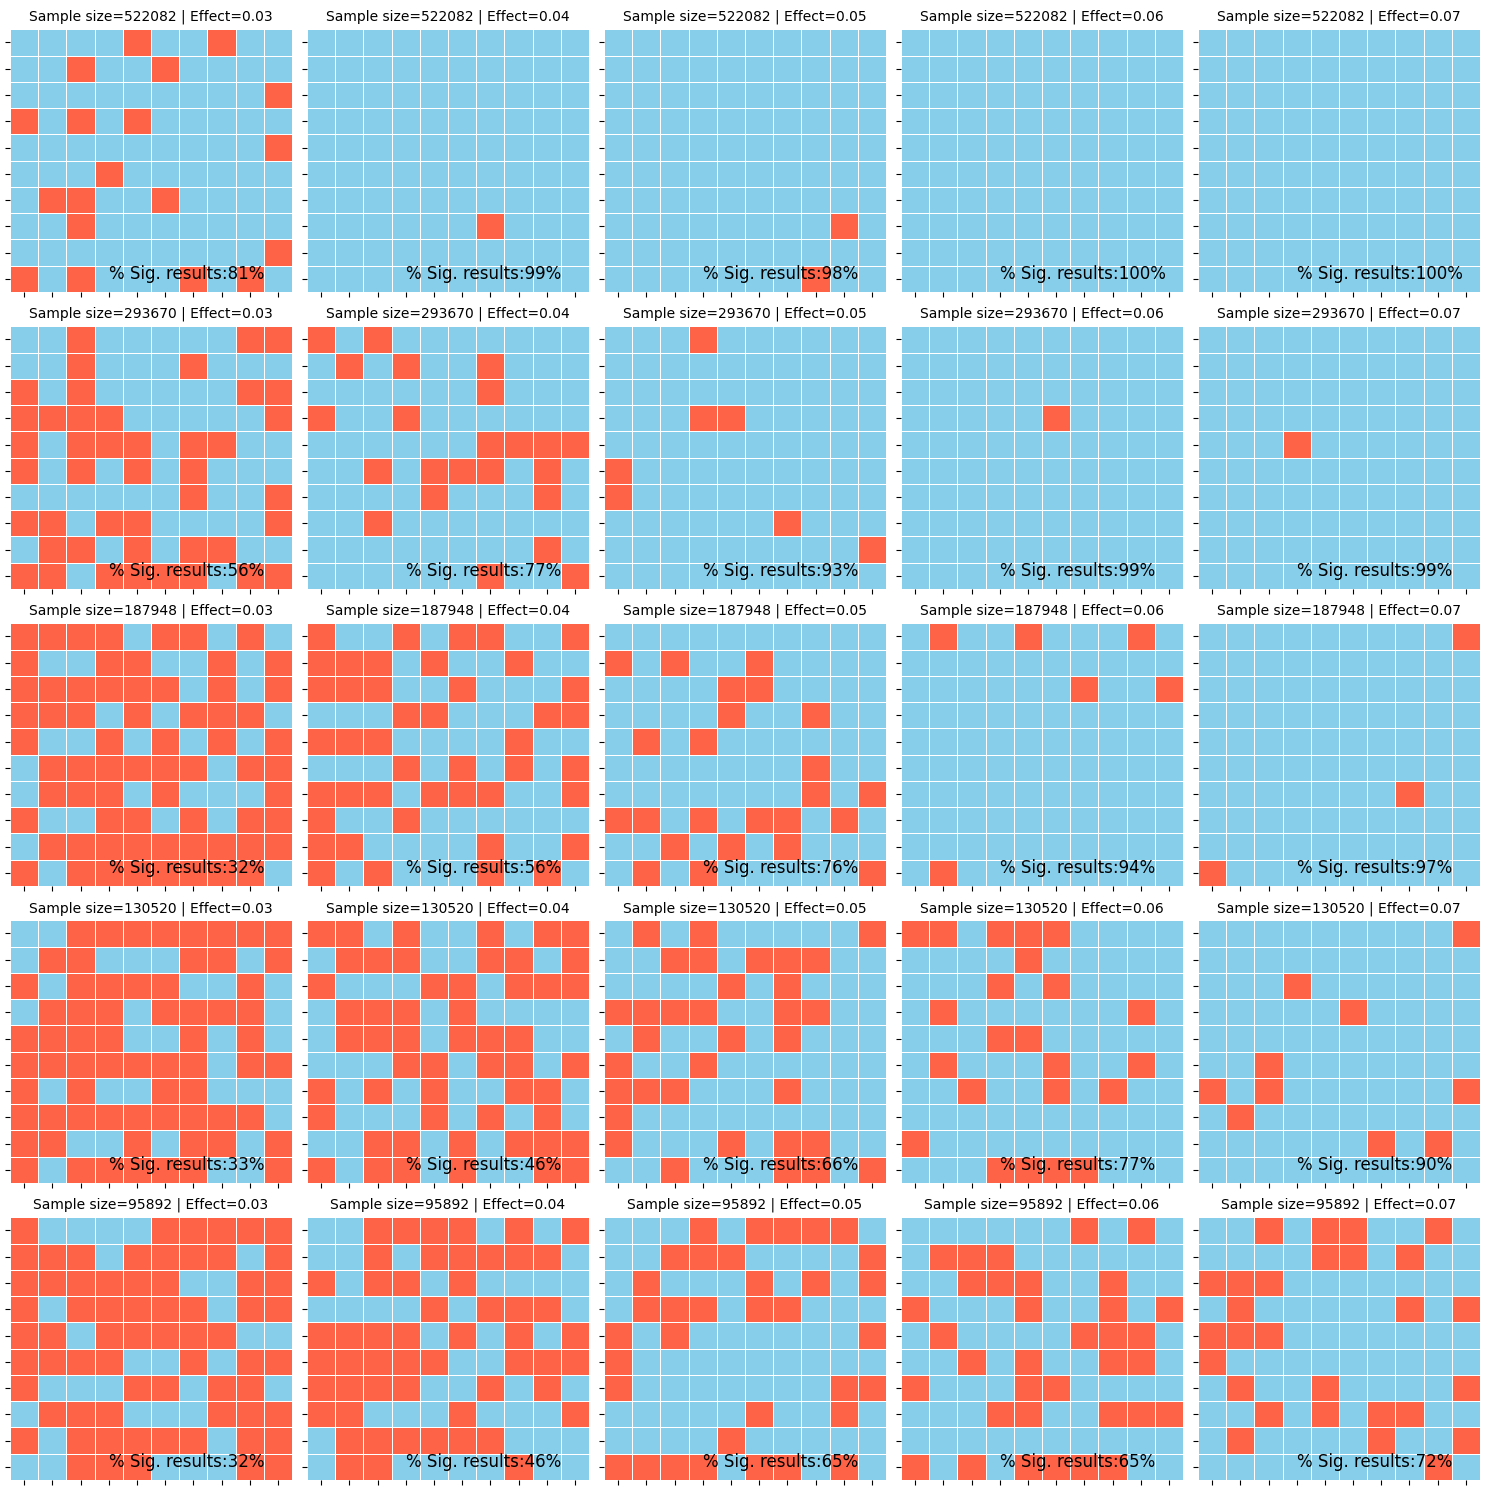

In [7]:
def draw_heatmap(data, row_var, col_var, value_var, **kwargs):
    data_pivot = data.pivot(
        index=row_var, columns=col_var, values=value_var
    )
    sns.heatmap(
        data_pivot,
        **kwargs
    )
    

def annotate_mean(data, metric, **kwargs):
    tx_mean = data[metric].mean()
    tx_mean = f"% Sig. results:{data[metric].mean():.0%}"
    txkw = dict(size=12)
    plt.text(3.5, 9.5, tx_mean, **txkw)
    

g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

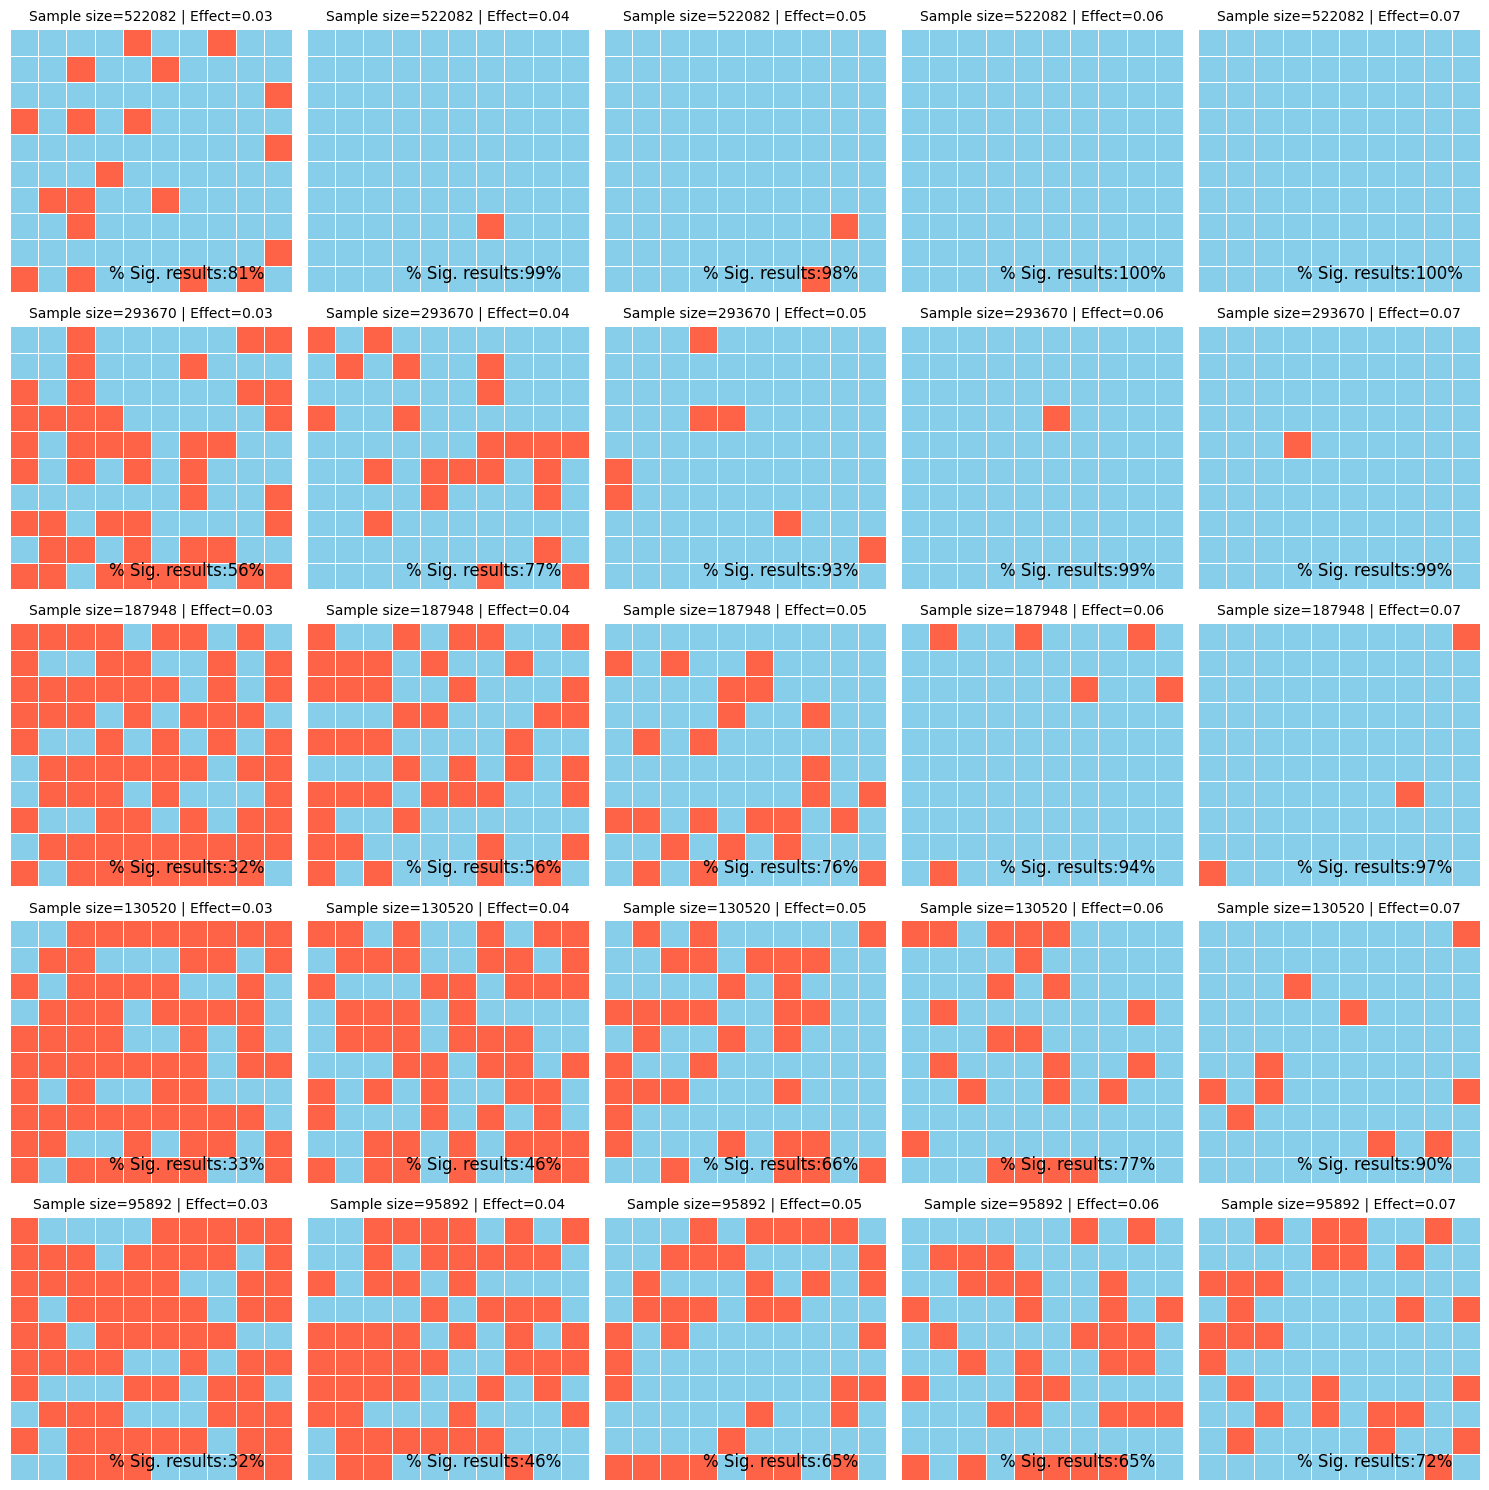

In [8]:
g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

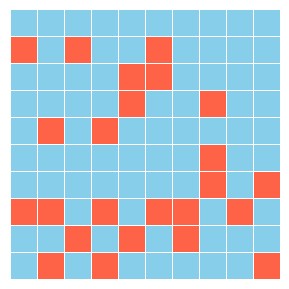

In [9]:
g = sns.FacetGrid(
        (stats.loc[
        (stats['count_sig']>=10) &
        (stats['sample_size']==187948) &
        (stats['true_effect']==0.05)
    ]),
#     col='true_effect',
#     row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
    
)
g.map_dataframe(draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0,vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False
               )
# g.map_dataframe(annotate_mean, metric='sig_at')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    
# g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

In [10]:
stats.head()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
"0.03,52208200,0",0.024090,0.003995,0.044592,0.048178,0.03,522082,0.0,0.0,1,81
"0.03,52208200,1",0.053453,0.032923,0.074403,0.000013,0.03,522082,0.0,1.0,1,81
"0.03,52208200,2",0.036494,0.016398,0.056995,0.002602,0.03,522082,0.0,2.0,1,81
"0.03,52208200,3",0.028274,0.008240,0.048713,0.019759,0.03,522082,0.0,3.0,1,81
"0.03,52208200,4",0.010567,-0.009120,0.030647,0.379478,0.03,522082,0.0,4.0,0,19


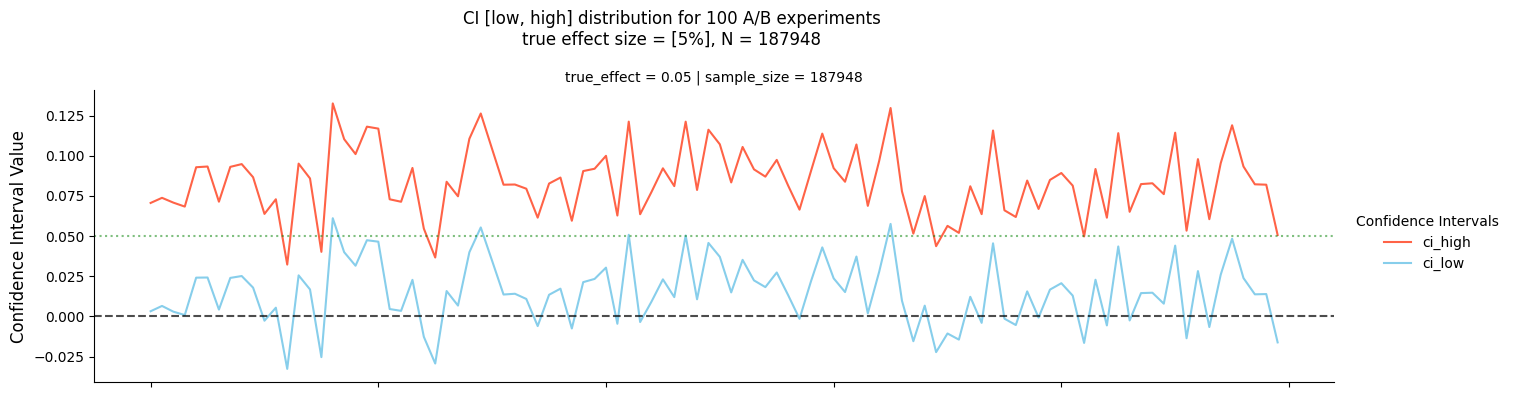

In [11]:
stats['index'] = [i for i in range(len(stats))]

stats_plot = stats.loc[
        (stats['true_effect']==0.05) & (stats['sample_size']==187948)  
             ]

g = sns.FacetGrid(
    stats_plot,
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_h',
    color='tomato',
    label='ci_high'
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_l',
    color='skyblue',
    label='ci_low'
)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
g.refline(y=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.5)


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('CI')
    ax.set_xticklabels([])
    
# Add axis labels
g.set_axis_labels('', 'Confidence Interval Value', fontsize=12)

# Add legend
g.add_legend(title='Confidence Intervals', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.12, 0.5), frameon=False)
    
g.fig.suptitle(f"CI [low, high] distribution for 100 A/B experiments\ntrue effect size = [{stats_plot.true_effect.unique()[0]:.0%}], N = {stats_plot.sample_size.unique()[0]}")
g.fig.tight_layout()


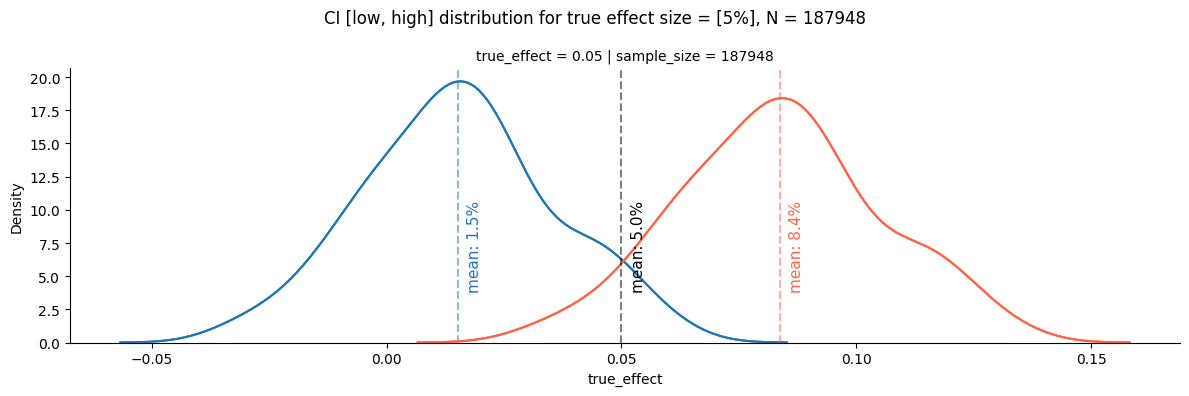

In [12]:
g = sns.FacetGrid(
    stats.loc[
        (stats['true_effect']==0.05) & (stats['sample_size']==187948)  
             ],
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(sns.kdeplot, x='ci_l')
g.map(sns.kdeplot, 'ci_l')
g.map(vertical_plot_lines, 'ci_l', xal=0.002, yal=4)

g.map_dataframe(sns.kdeplot, x='ci_h', color='tomato')
g.map(sns.kdeplot, 'ci_h', color='tomato')
g.map(vertical_plot_lines, 'ci_h', color='tomato', xal=0.002, yal=4)
g.map(vertical_plot_lines, 'true_effect', linestyle = '--', color='black', xal=0.002, yal=4)

g.fig.suptitle("CI [low, high] distribution for true effect size = [5%], N = 187948")
g.fig.tight_layout()

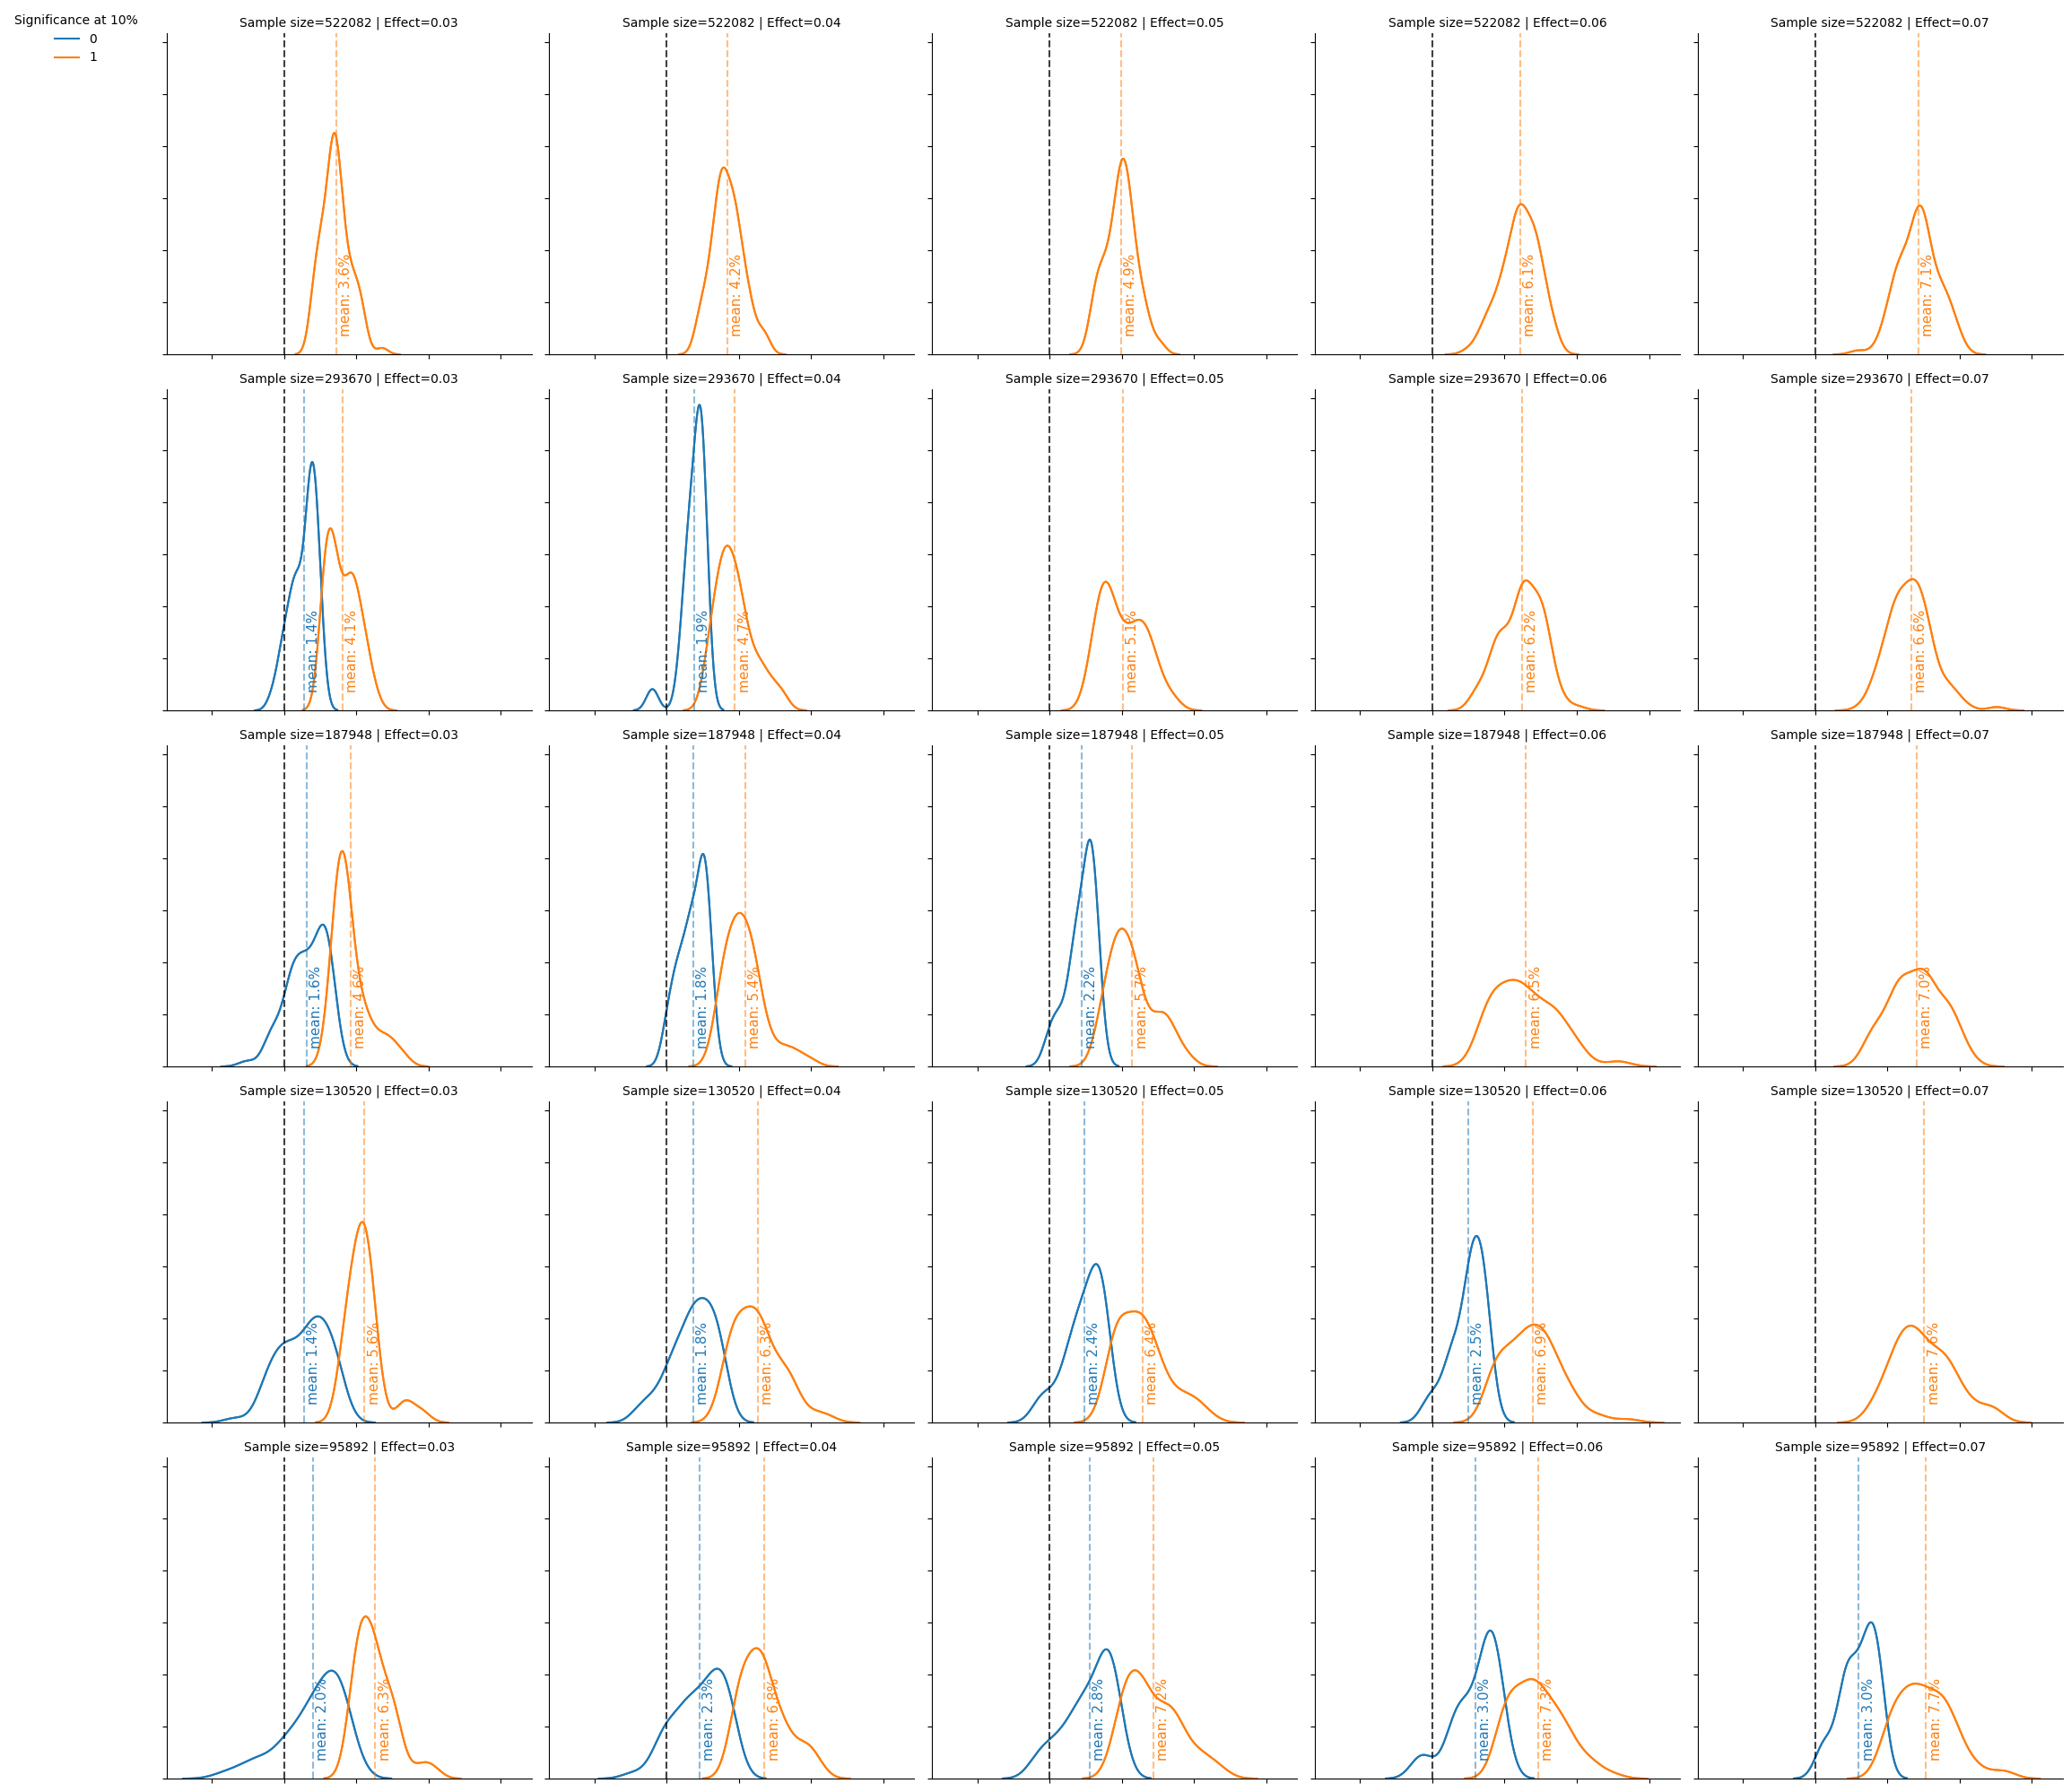

In [13]:
g = sns.FacetGrid(
    stats.loc[stats['count_sig']>=20],
    col='true_effect',
    row='sample_size',
    hue='sig_at',
    height=4, aspect=1, sharex=True,
    row_order=sample_sizes
    
)
g.map_dataframe(sns.kdeplot, x='estimate')
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)
# g.map(vertical_plot_lines, 'true_effect', xal=0.005, yal=50, color='tomato')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.axvline(0, linestyle = '--', color = "black", alpha = 0.75)
# plt.axvline(stats['true_effect'].mean(), linestyle = ':', color = "black", alpha = 0.75)
# plt.text(stats['true_effect'].mean()+0.0015, 4, f"True effect: {stats['true_effect'].mean():.1%}", rotation=90)
    
    
g.add_legend(title="Significance at 10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(0, 1), frameon=False)
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

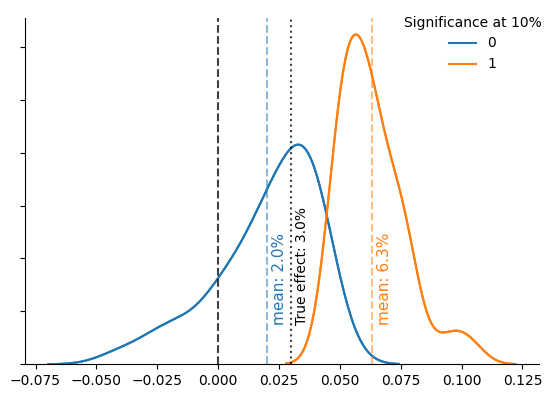

In [14]:
plot_stats = stats.loc[
        (stats['count_sig']>=10) &
        (stats['sample_size']<96892) &
        (stats['true_effect']==0.03)
    ]

g = sns.FacetGrid(
    plot_stats,
#     col='true_effect',
#     row='sample_size',
    hue='sig_at',
    height=4, aspect=1, sharex=True,
    row_order=sample_sizes
    
)
g.map_dataframe(sns.kdeplot, x='estimate')
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)
# g.map(vertical_plot_lines, 'true_effect', xal=0.005, yal=50, color='tomato')


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
#     ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.axvline(0, linestyle = '--', color = "black", alpha = 0.75)
plt.axvline(plot_stats['true_effect'].mean(), linestyle = ':', color = "black", alpha = 0.75)
plt.text(plot_stats['true_effect'].mean()+0.0015, 4, f"True effect: {plot_stats['true_effect'].mean():.1%}", rotation=90)
    
    
g.add_legend(title="Significance at 10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 1), frameon=False)
g.set_titles(row_template="Sample size={row_name}", col_template="Effect={col_name}")
g.figure.tight_layout()

# Non parametric test

In [15]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle = '--', color = kwargs.get("color", "g"), alpha = 0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color = kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean()+xal, yal, tx_mean, **txkw)


def plot_distribution(df, metric, **kwargs):
    g = sns.FacetGrid(
        data=df,
        aspect=3, height = 5,
        hue = 'variant', row = kwargs.get('row',None)
    ) 
    g.map(sns.distplot, metric, hist=kwargs.get('displot_hist',False), kde_kws={'bw': kwargs.get('kde_bandwidth','silverman')})
    g.map(vertical_plot_lines, metric, xal=  kwargs.get('xal',0.10), yal=kwargs.get('yal',0.5))
    g.fig.suptitle("Distribution between variants - {}".format(metric))
    g.set_xlabels("{}".format(metric))
    g.set_ylabels("density")
    g.set(xlim = kwargs.get('xlim', (-10,10)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color="black", ls=':')
        
        
def get_mann_whitney_test(data, metric_field, confidence=0.9):
    array_base = data.loc[data['variant'] == 0, metric_field]
    array_variant = data.loc[data['variant'] == 1, metric_field]
    u_value, p_value = mannwhitneyu(array_base, array_variant)
    
    print("Mann-Whitney p-value: {:.5f} \nstatstistical significance at {} level p_value < (1 - confidence): {}\n".format(
        p_value, confidence, p_value<(1-confidence)))
    
    return u_value, p_value
                
    

/opt/homebrew/lib/python3.9/site-packages/seaborn/axisgrid.py:848: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/opt/homebrew/lib/python3.9/site-packages/seaborn/distributions.py:2511: UserWarning:



The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=silverman`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.13.0.


/opt/homebrew/lib/python3.9/site-packages/seaborn/axisgrid.py:848: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level funct

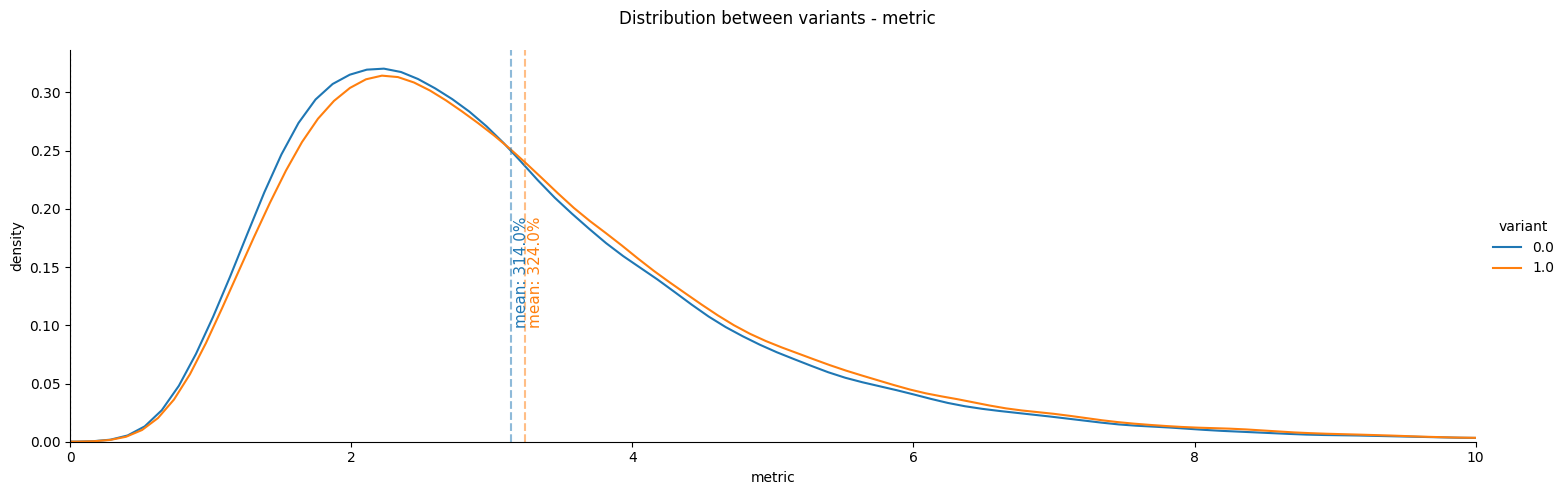

In [16]:
df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,SAMPLE_SIZE))})

df_exp['metric'] = np.random.lognormal(
    1.02, 
    .5,
    SAMPLE_SIZE
)

df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.lognormal(
    1.05, 
    .5,
    size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
)

plot_distribution(
    df_exp, 
    'metric', xlim=(0,10),
    yal=0.1, xal=0.02)

In [17]:
get_mann_whitney_test(df_exp, 'metric', confidence=0.9)

Mann-Whitney p-value: 0.00000 
statstistical significance at 0.9 level p_value < (1 - confidence): True



(7538704808.0, 5.2815997642055684e-52)

# A/A simulations

In [18]:
def run_simulation(
    num_simulations=500,
    sample_size=100000,
    true_effect = 0.0,
    base_rate = 0.05,
    ci_l_threshold = -0.01
):       
    counter_trending = 0
    counter_result_changed = 0
    responses = {}
    for i in range(num_simulations):

        df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

        df_exp['metric'] = np.random.binomial(
            n=1, 
            p=base_rate, 
            size=sample_size
        )

        df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
            n=1, 
            p=base_rate * (1 + true_effect), 
            size=df_exp.loc[df_exp.variant == 1, 'metric'].shape[0]
        )

        response = get_results(
            df_exp, 
            metric_field='metric', 
            confidence=0.9, 
            threshold=None, 
            calculate_ratio=True,
            plot=False
        )

        if (response['ci_l'] > ci_l_threshold) & (response['ci_l'] <= 0):

            counter_trending += 1

            df_exp_2 = pd.DataFrame({'variant': np.round(np.random.uniform(0,1,sample_size))})

            df_exp_2['metric'] = np.random.binomial(
                n=1, 
                p=base_rate, 
                size=sample_size
            )

            df_exp_2.loc[df_exp_2.variant == 1, 'metric'] = np.random.binomial(
                n=1, 
                p=BASE_RATE * (1 + true_effect), 
                size=df_exp_2.loc[df_exp_2.variant == 1, 'metric'].shape[0]
            )

            df_exp = pd.concat([df_exp, df_exp_2])

            response_2 = get_results(
                df_exp, 
                metric_field='metric', 
                confidence=0.9, 
                threshold=None, 
                calculate_ratio=True,
                plot=False
            )

            if response_2['ci_l'] > 0:
                counter_result_changed += 1


        response['true_effect'] = true_effect
        response['sample_size'] = sample_size
        response['index_row'] = int(i // 10)
        response['index_col'] = int(i % 10)

        responses[f'{true_effect},{sample_size*100},{i}'] = response

    stats = pd.DataFrame(responses).T 
    stats['sample_size'] = stats['sample_size'].apply(int)
    stats['sig_at'] = stats['p-value'] <= 0.1
    stats['sig_at'] = stats['sig_at'] * 1

    stats['count_sig'] = stats.groupby(['true_effect','sample_size','sig_at'])['sig_at'].transform('count')
    
    return stats, counter_trending, counter_result_changed

In [27]:
RANGE = 1000
stats, counter_trending, counter_result_changed = run_simulation(
    num_simulations=RANGE,
    sample_size=100000,
    true_effect = 0.0,
    base_rate = 0.05,
    ci_l_threshold = -0.01
)

print(f"CI trending: {counter_trending}, % of total: {counter_trending/RANGE:.2%}")
print(f"Result changed after run longer: {counter_result_changed}, % of total: {counter_result_changed/RANGE:.2%}")

CI trending: 494, % of total: 4.94%
Result changed after run longer: 113, % of total: 1.13%


In [28]:
stats.describe()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.0,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.000286,-0.044083,0.046717,0.501466,0.0,100000.0,499.500000,4.500000,0.100400,8193.603200
std,0.027511,0.026300,0.028813,0.287805,0.0,0.0,288.689425,2.872425,0.300548,2401.976592
min,-0.096888,-0.136674,-0.055375,0.000192,0.0,100000.0,0.000000,0.000000,0.000000,1004.000000
25%,-0.018718,-0.062228,0.026844,0.253829,0.0,100000.0,249.750000,2.000000,0.000000,8996.000000
50%,-0.000472,-0.044805,0.045983,0.501291,0.0,100000.0,499.500000,4.500000,0.000000,8996.000000
75%,0.018435,-0.026792,0.065708,0.751168,0.0,100000.0,749.250000,7.000000,0.000000,8996.000000
max,0.105034,0.056156,0.156316,0.999908,0.0,100000.0,999.000000,9.000000,1.000000,8996.000000


In [22]:
print(((stats.ci_l >= 0.0) | (stats.ci_h <= 0.0)).mean()) # alpha | false positive
print(((stats.ci_l >= -0.01) | (stats.ci_h <= 0.01)).mean()) # borderline alpha | false positive
print(((stats.ci_l >= -0.02) | (stats.ci_h <= 0.02)).mean()) # borderline alpha | false positive

0.101
0.213
0.362


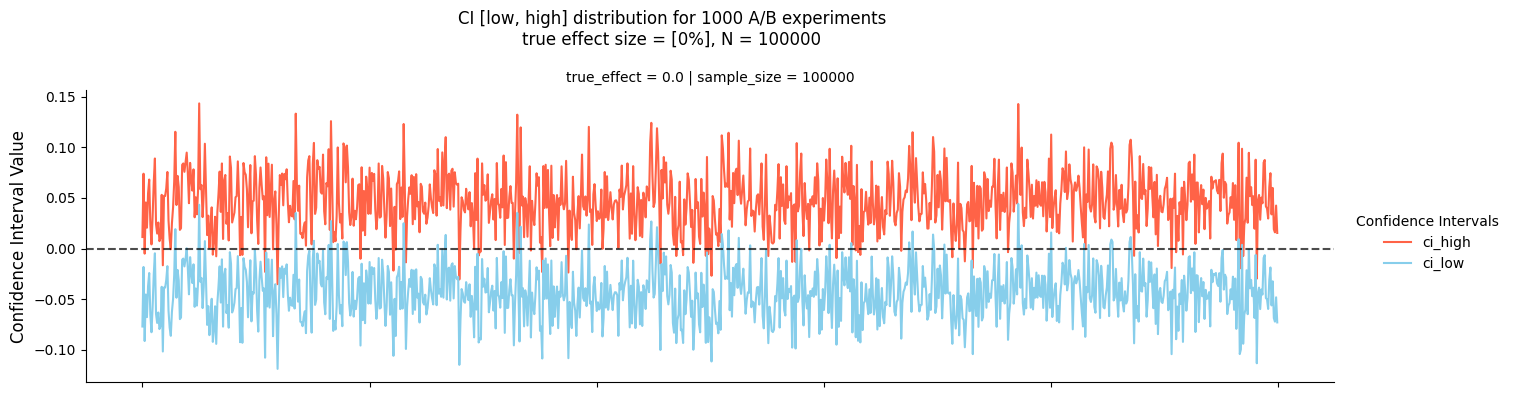

In [23]:
stats['index'] = [i for i in range(len(stats))]

stats_plot = stats.copy()

g = sns.FacetGrid(
    stats_plot,
    col = 'sample_size', row = 'true_effect',
    height=4, aspect=3, sharex=True, 
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_h',
    color='tomato',
    label='ci_high'
)

g.map_dataframe(
    sns.lineplot,
    x='index',
    y='ci_l',
    color='skyblue',
    label='ci_low'
)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# g.refline(y=0.05, color='green', linestyle=':', linewidth=1.5, alpha=0.5)


for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('CI')
    ax.set_xticklabels([])
    
# Add axis labels
g.set_axis_labels('', 'Confidence Interval Value', fontsize=12)

# Add legend
g.add_legend(title='Confidence Intervals', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.12, 0.5), frameon=False)
    
g.fig.suptitle(f"CI [low, high] distribution for {RANGE} A/B experiments\ntrue effect size = [{stats_plot.true_effect.unique()[0]:.0%}], N = {stats_plot.sample_size.unique()[0]}")
g.fig.tight_layout()
